In [1]:
import math
import random
from collections.abc import Callable

import matplotlib.pyplot as plt

from jacinta.processor.evaluator import ZScoreEvaluator

In [2]:
# hyperparameters
MEAN_EMA_RATE = 0.001
VAR_EMA_RATE = 0.001

# simulation parameters
N_STEPS = 10000
N_PLOTS = 5
SEED = 42

In [3]:
def plot_feedback_statistics(
    ax: plt.Axes,
    mean_function: Callable[[int], float],
    var_function: Callable[[int], float],
) -> None:
    """
    Plot the feedback statistics.

    Args:
        ax (plt.Axes): The axes to plot on.
        mean_function (Callable[[int], float]): The feedback mean function.
        var_function (Callable[[int], float]): The feedback variance function.
    """
    # get the simulation steps
    steps = list(range(N_STEPS))
    # evaluate the feedback statistics
    means = [mean_function(step) for step in steps]
    stds = [math.sqrt(var_function(step)) for step in steps]
    # plot the feedback statistics
    ax.plot(steps, means, label="Mean")
    for idx, (scale, alpha) in enumerate(
        (
            (1.0, 0.025000),
            (0.8, 0.025641),
            (0.6, 0.052632),
            (0.4, 0.111111),
            (0.2, 0.125000),
        )
    ):
        # get the feedback distribution bounds
        lower_bounds = [
            mean - scale * std for mean, std in zip(means, stds, strict=True)
        ]
        upper_bounds = [
            mean + scale * std for mean, std in zip(means, stds, strict=True)
        ]
        ax.fill_between(
            steps,
            lower_bounds,
            upper_bounds,
            color="C0",
            alpha=alpha,
            label="Mean ± Std" if idx == 4 else None,
        )
    ax.set_xlim(0, N_STEPS)
    ax.set_xlabel("Step")
    ax.set_ylabel("Gaussian Feedback")
    ax.set_title("Gaussian Feedback Statistics")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

In [4]:
def plot_evaluator(
    ax: plt.Axes,
    evaluator: ZScoreEvaluator,
    n_points: int = 1000,
) -> None:
    """
    Plot the evaluator feedback-advantage mapping.

    Args:
        ax (plt.Axes): The axes to plot on.
        evaluator (ZScoreEvaluator): The evaluator to plot.
        n_points (int): The number of points to plot.
            Defaults to 1000.
    """
    # get the evaluator statistics
    mean = evaluator.mean
    std = math.sqrt(evaluator.var)
    # evaluate the feedback-advantage mapping
    min_f = mean - 4.0 * std
    max_f = mean + 4.0 * std
    f_step = (max_f - min_f) / (n_points - 1)
    feedbacks = [min_f + idx * f_step for idx in range(n_points)]
    advantages = [(feedback - mean) / (std + evaluator.eps) for feedback in feedbacks]
    # plot the feedback-advantage mapping
    ax.plot(feedbacks, advantages)
    ax.axvline(mean - std, color="C1", linestyle="--", label="Mean ± Std")
    ax.axvline(mean, color="C0", linestyle="--", label="Mean")
    ax.axvline(mean + std, color="C1", linestyle="--")
    ax.set_xlim(min_f, max_f)
    ax.set_xlabel("Feedback")
    ax.set_ylabel("Advantage")
    ax.set_title("Evaluator Feedback-Advantage Mapping")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

In [5]:
def plot_evaluator_statistics(
    ax: plt.Axes,
    means: list[float],
    vars: list[float],
) -> None:
    """
    Plot the evaluator statistics.

    Args:
        ax (plt.Axes): The axes to plot on.
        means (list[float]): The evaluator means.
        vars (list[float]): The evaluator variances.
    """
    # get the simulation steps
    steps = list(range(len(means)))
    # get the evaluator statistics
    stds = [math.sqrt(var) if math.isfinite(var) else math.nan for var in vars]
    # get the evaluator distribution bounds
    lower_bounds = [mean - std for mean, std in zip(means, stds, strict=True)]
    upper_bounds = [mean + std for mean, std in zip(means, stds, strict=True)]
    # plot the evaluator statistics
    ax.plot(steps, means, label="Mean")
    ax.fill_between(steps, lower_bounds, upper_bounds, alpha=0.125, label="Mean ± Std")
    ax.set_xlim(0, len(means))
    ax.set_xlabel("Step")
    ax.set_ylabel("Evaluator Feedback")
    ax.set_title("Evaluator Feedback Statistics")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

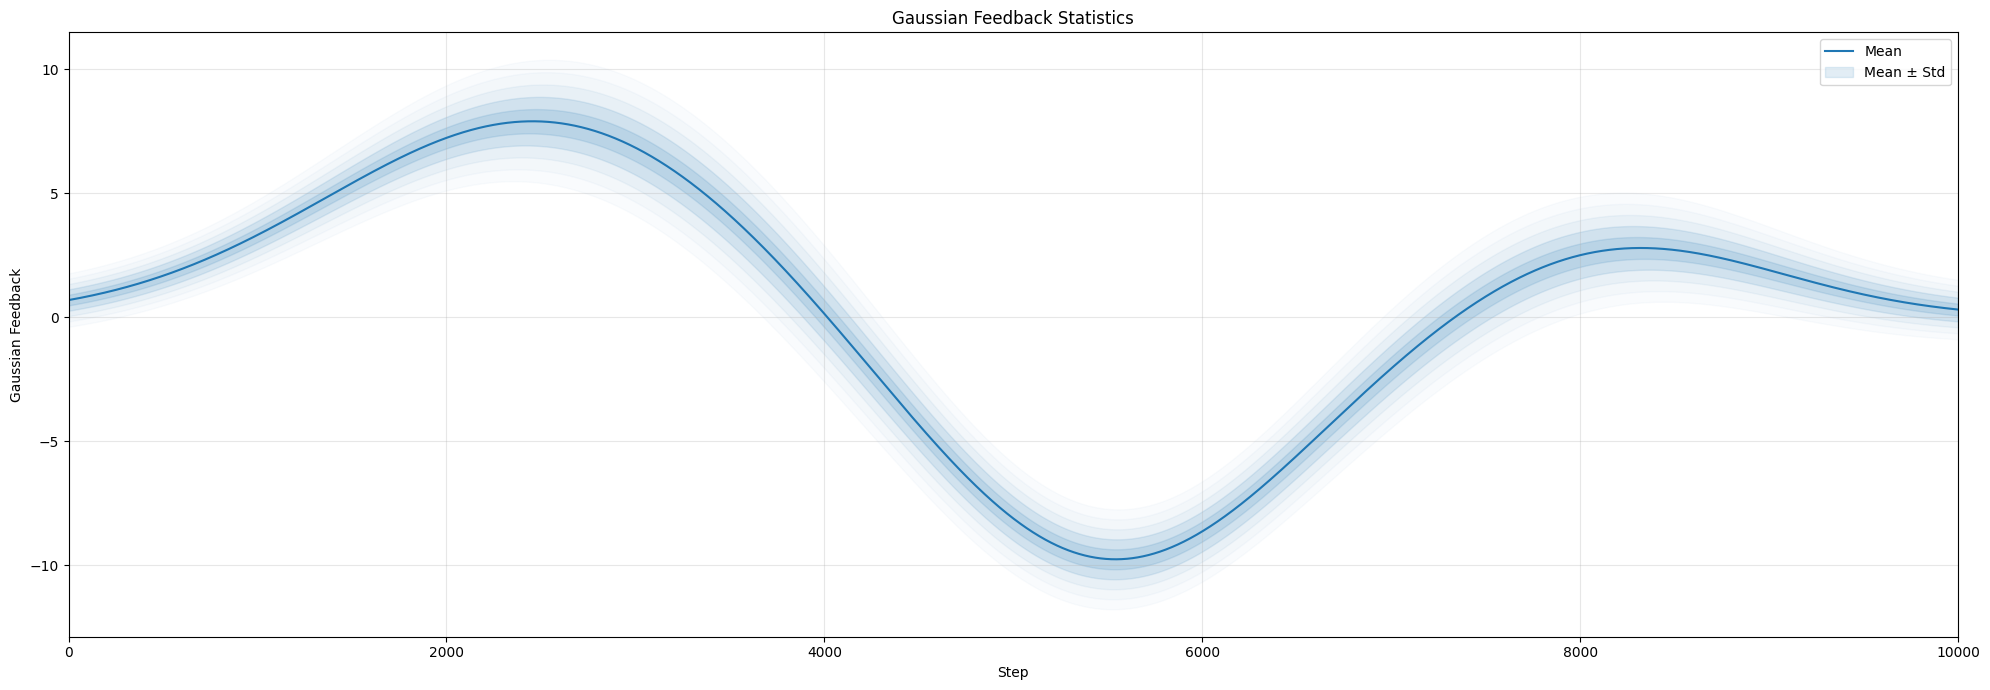

In [6]:
def mean_function(step: int) -> float:
    """
    Mean function.

    Args:
        step (int): The simulation step.

    Returns:
        float: The feedback mean at the given simulation step.
    """
    mean = (
        8.0 * math.exp(-(((step / (N_STEPS - 1) - 0.25) / 0.16) ** 2))
        - 10.0 * math.exp(-(((step / (N_STEPS - 1) - 0.55) / 0.14) ** 2))
        + 3.0 * math.exp(-(((step / (N_STEPS - 1) - 0.82) / 0.12) ** 2))
    )
    return mean


def var_function(step: int) -> float:
    """
    Variance function.

    Args:
        step (int): The simulation step.

    Returns:
        float: The feedback variance at the given simulation step.
    """
    var = (
        1.0
        + 7.0 * math.exp(-(((step / (N_STEPS - 1) - 0.35) / 0.18) ** 2))
        + 5.0 * math.exp(-(((step / (N_STEPS - 1) - 0.75) / 0.16) ** 2))
    )
    return var


# plot the feedback statistics
fig, ax = plt.subplots(figsize=(20, 7))
plot_feedback_statistics(ax, mean_function, var_function)
fig.tight_layout()
plt.show()

In [7]:
def sample_feedback(
    step: int,
    mean_function: Callable[[int], float],
    var_function: Callable[[int], float],
    rng: random.Random,
) -> float:
    """
    Sample feedback from the feedback distribution.

    Args:
        step (int): The simulation step.
        mean_function (Callable[[int], float]): The feedback mean function.
        var_function (Callable[[int], float]): The feedback variance function.
        rng (random.Random): The random number generator used for sampling.

    Returns:
        float: The sampled feedback.
    """
    # get the feedback distribution parameters
    mean = mean_function(step)
    var = var_function(step)
    # sample the feedback
    feedback = rng.gauss(mean, math.sqrt(var))
    return feedback

In [8]:
# initialize a ZScoreEvaluator
evaluator = ZScoreEvaluator(
    mean_ema_rate=MEAN_EMA_RATE,
    var_ema_rate=VAR_EMA_RATE,
)

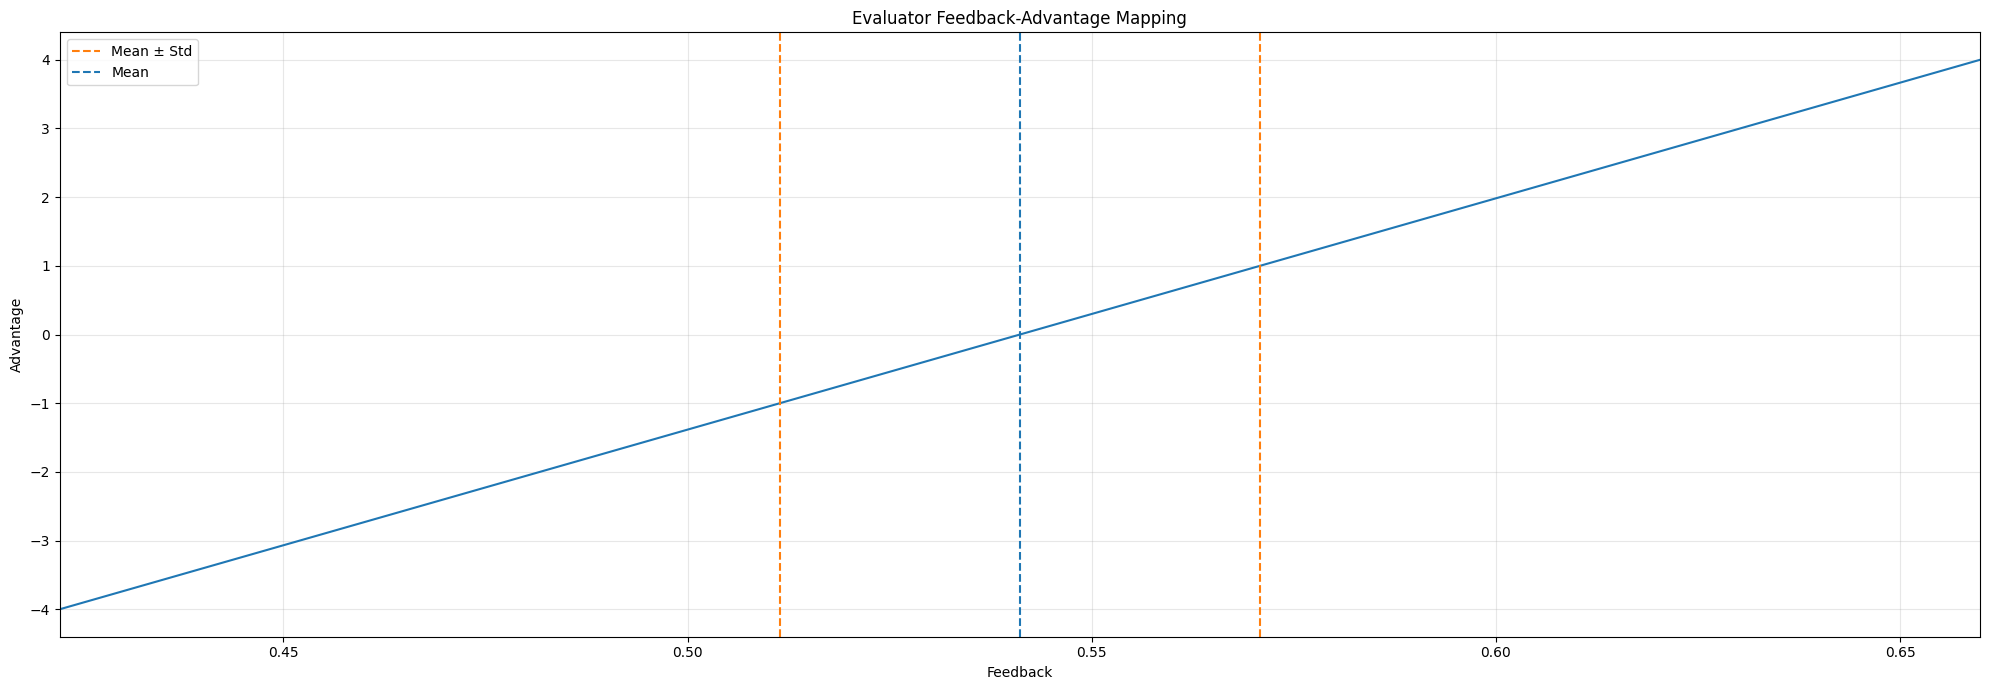

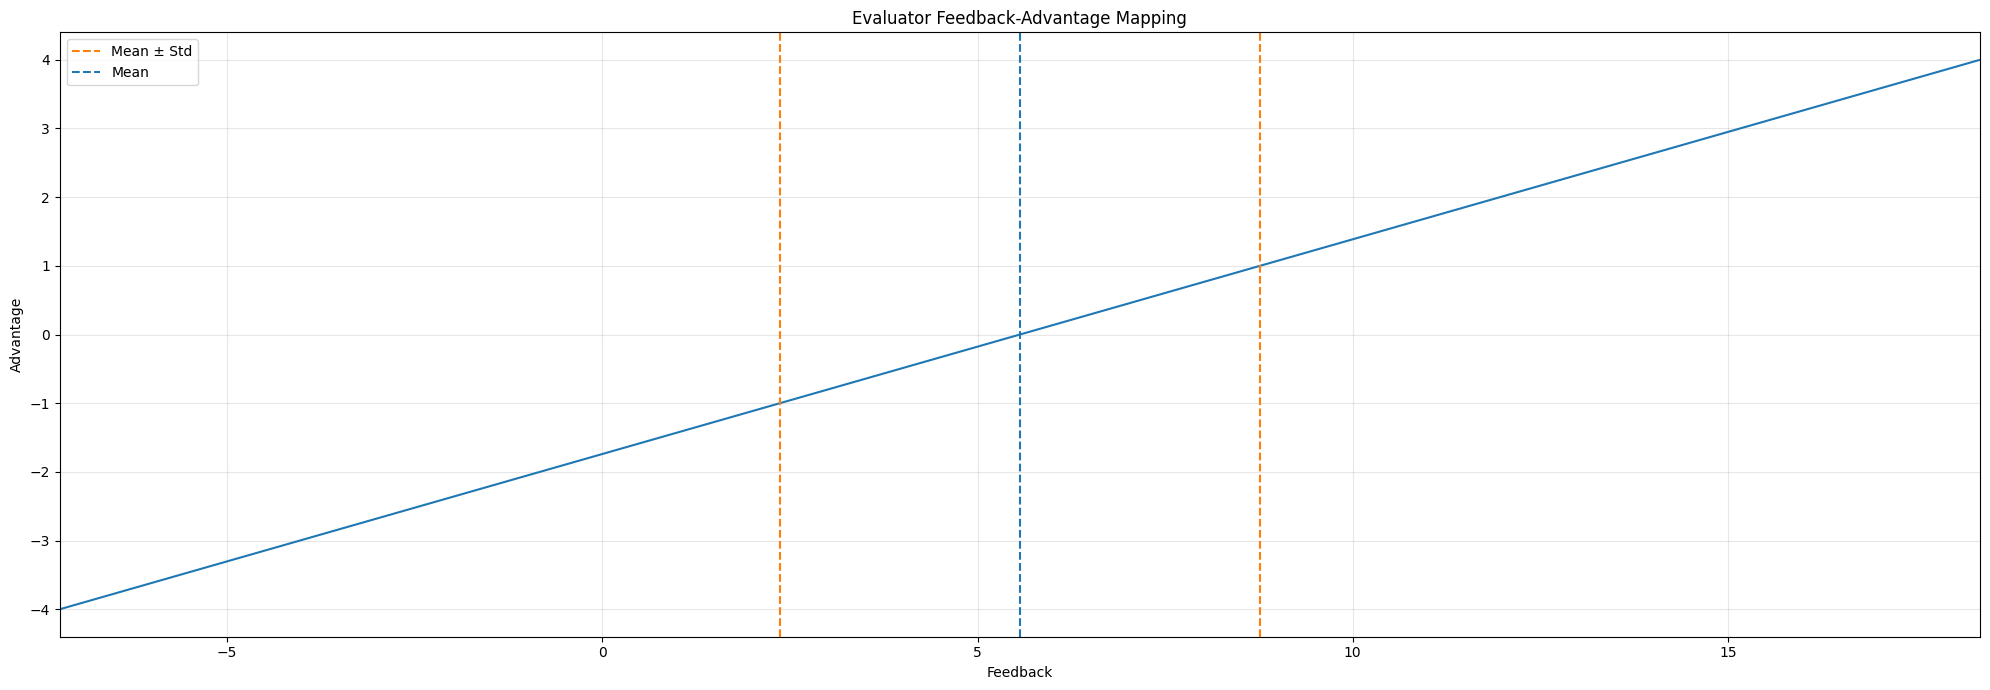

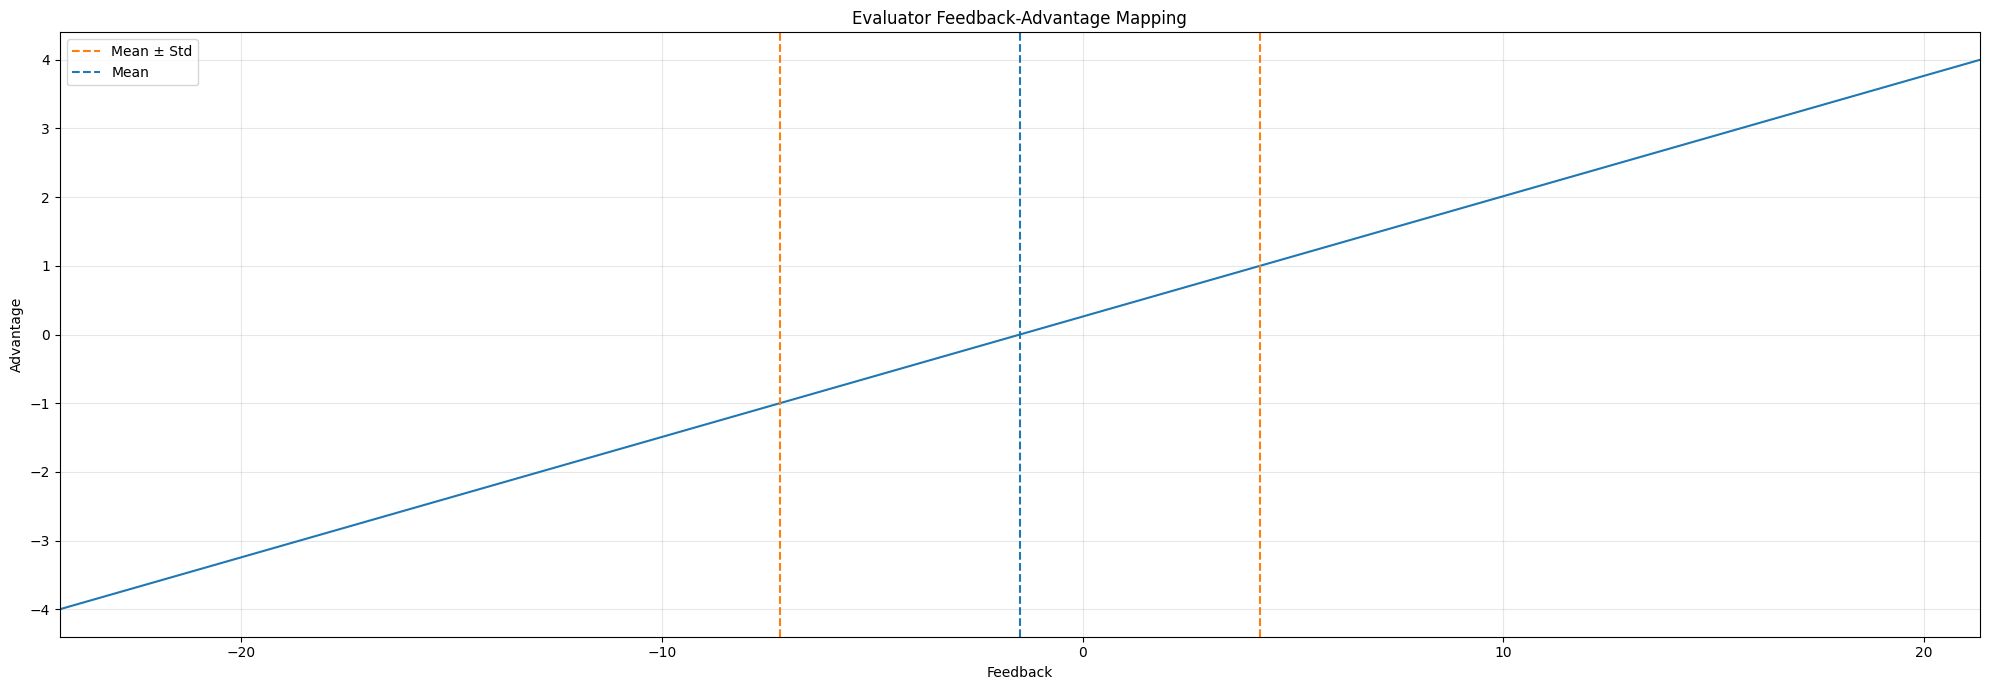

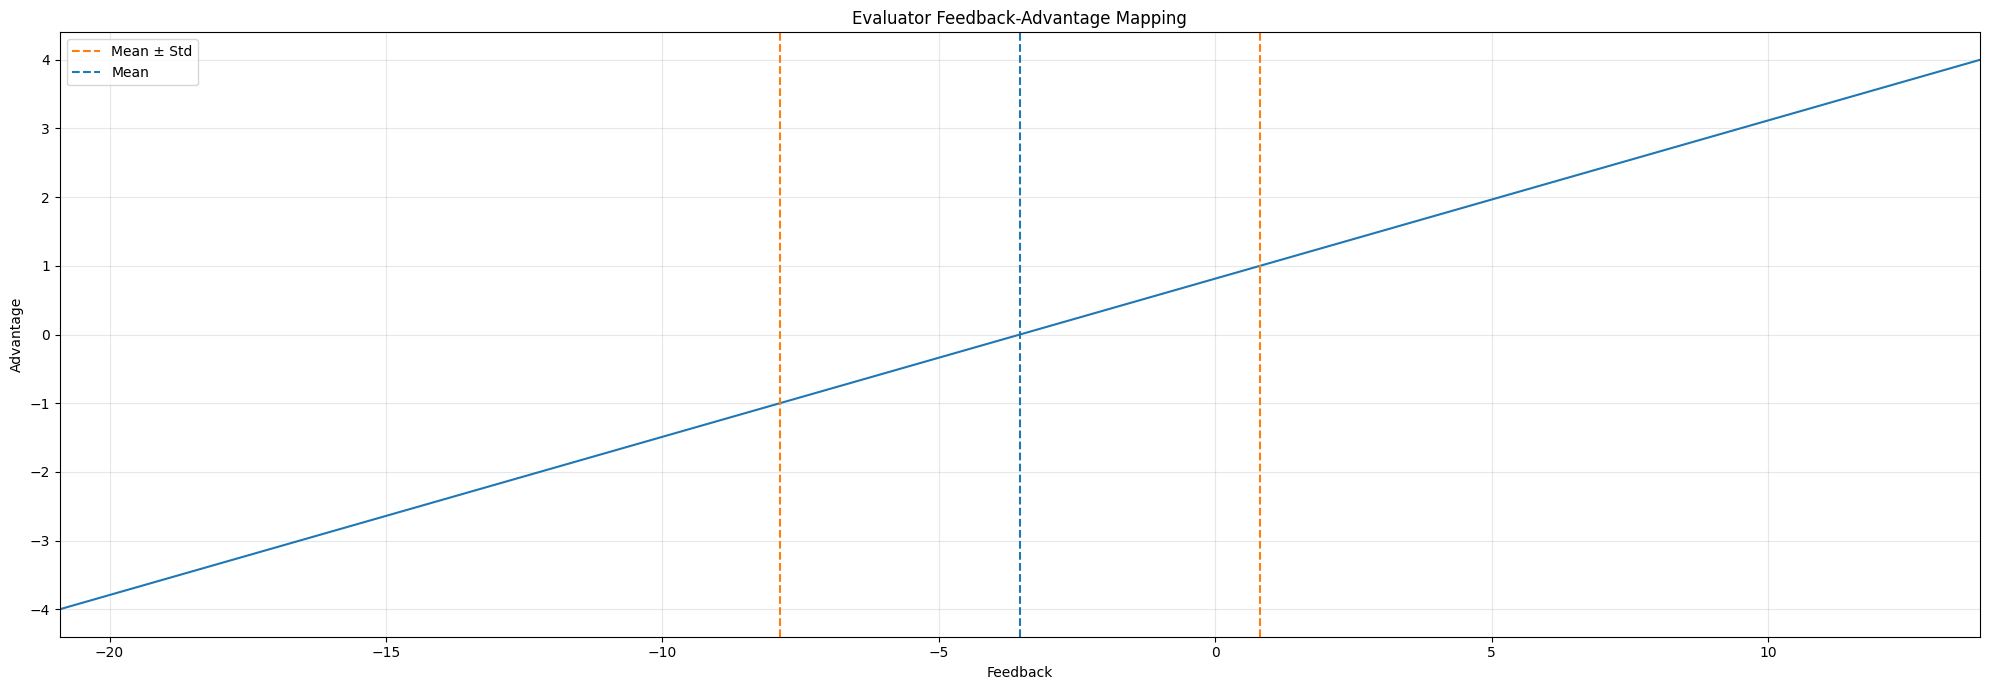

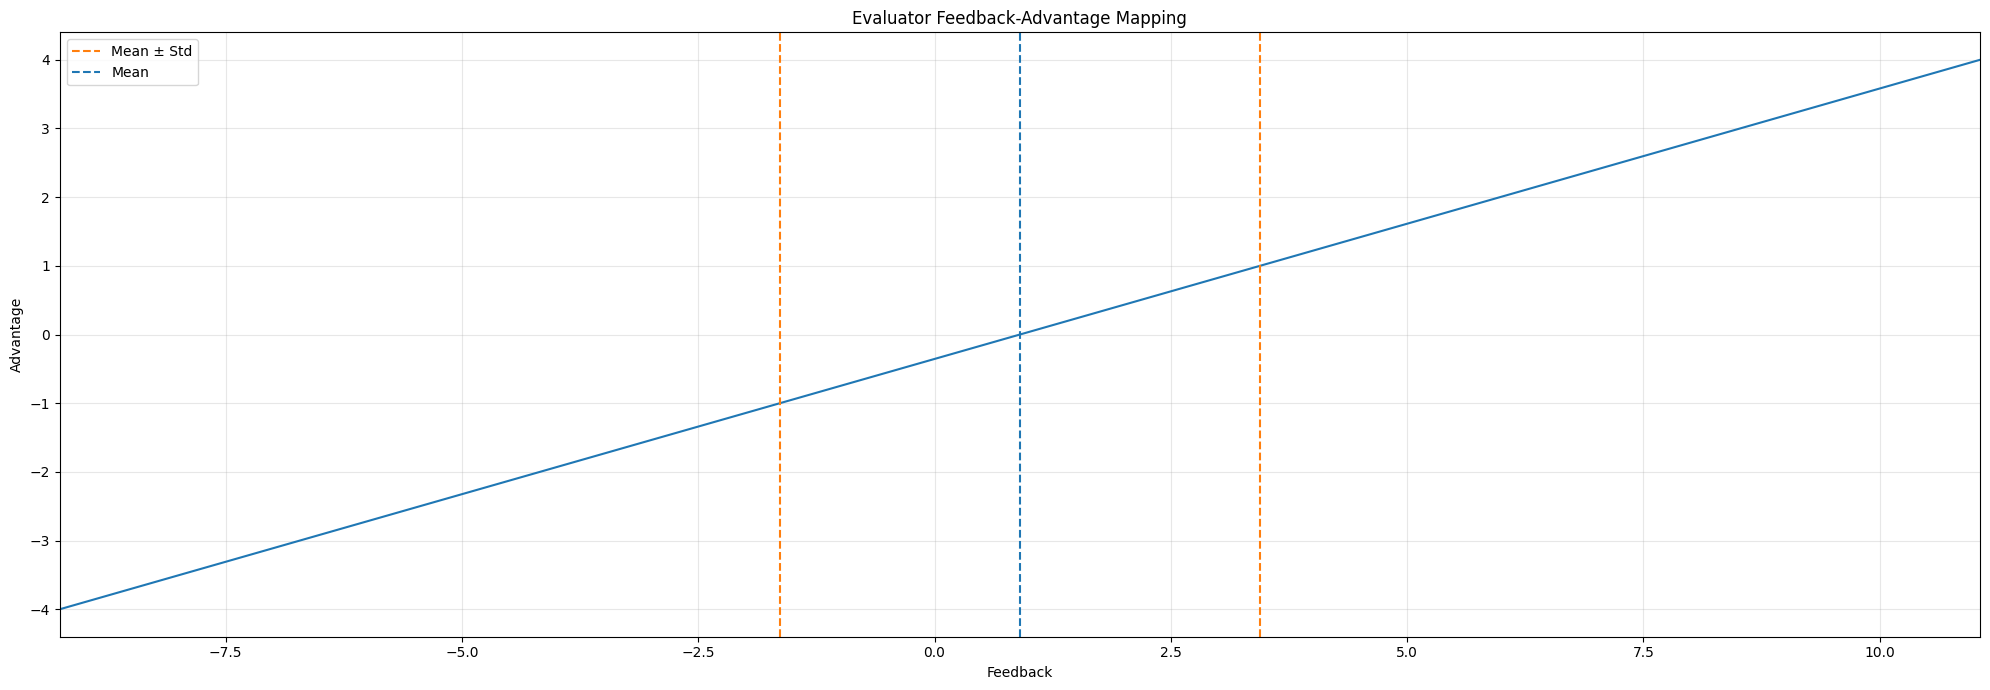

In [9]:
# initialize the random number generator
rng = random.Random(SEED)

# set the evaluator plot steps
plot_steps = (
    {round(1 + idx * (N_STEPS - 2) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    feedback = sample_feedback(step, mean_function, var_function, rng)
    evaluator(feedback)
    # plot the evaluator
    if step in plot_steps:
        fig, ax = plt.subplots(figsize=(20, 7))
        plot_evaluator(ax, evaluator)
        fig.tight_layout()
        plt.show()

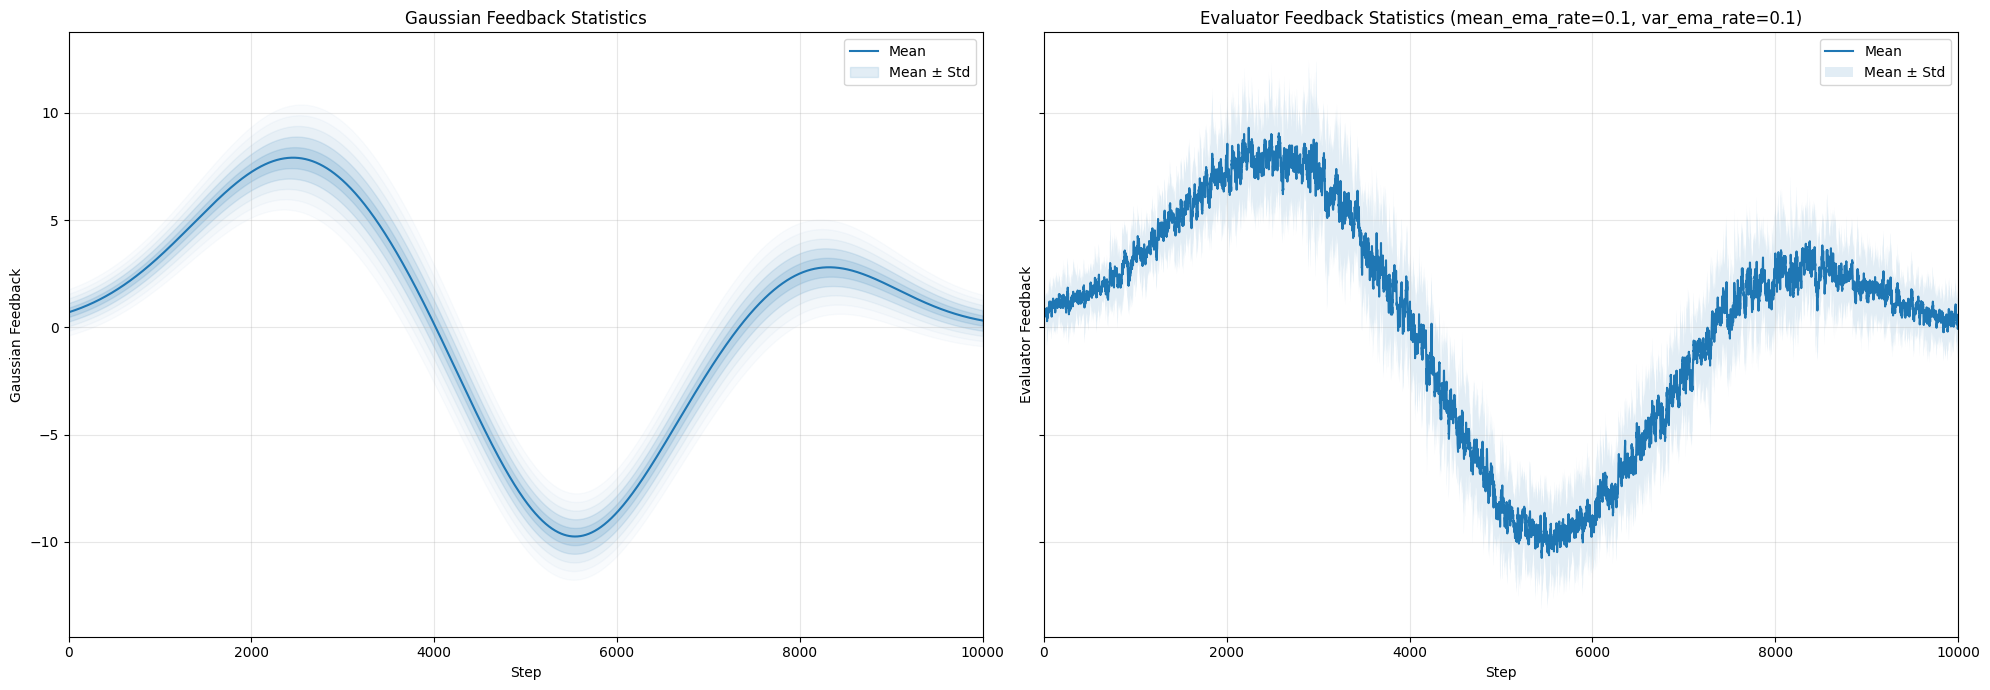

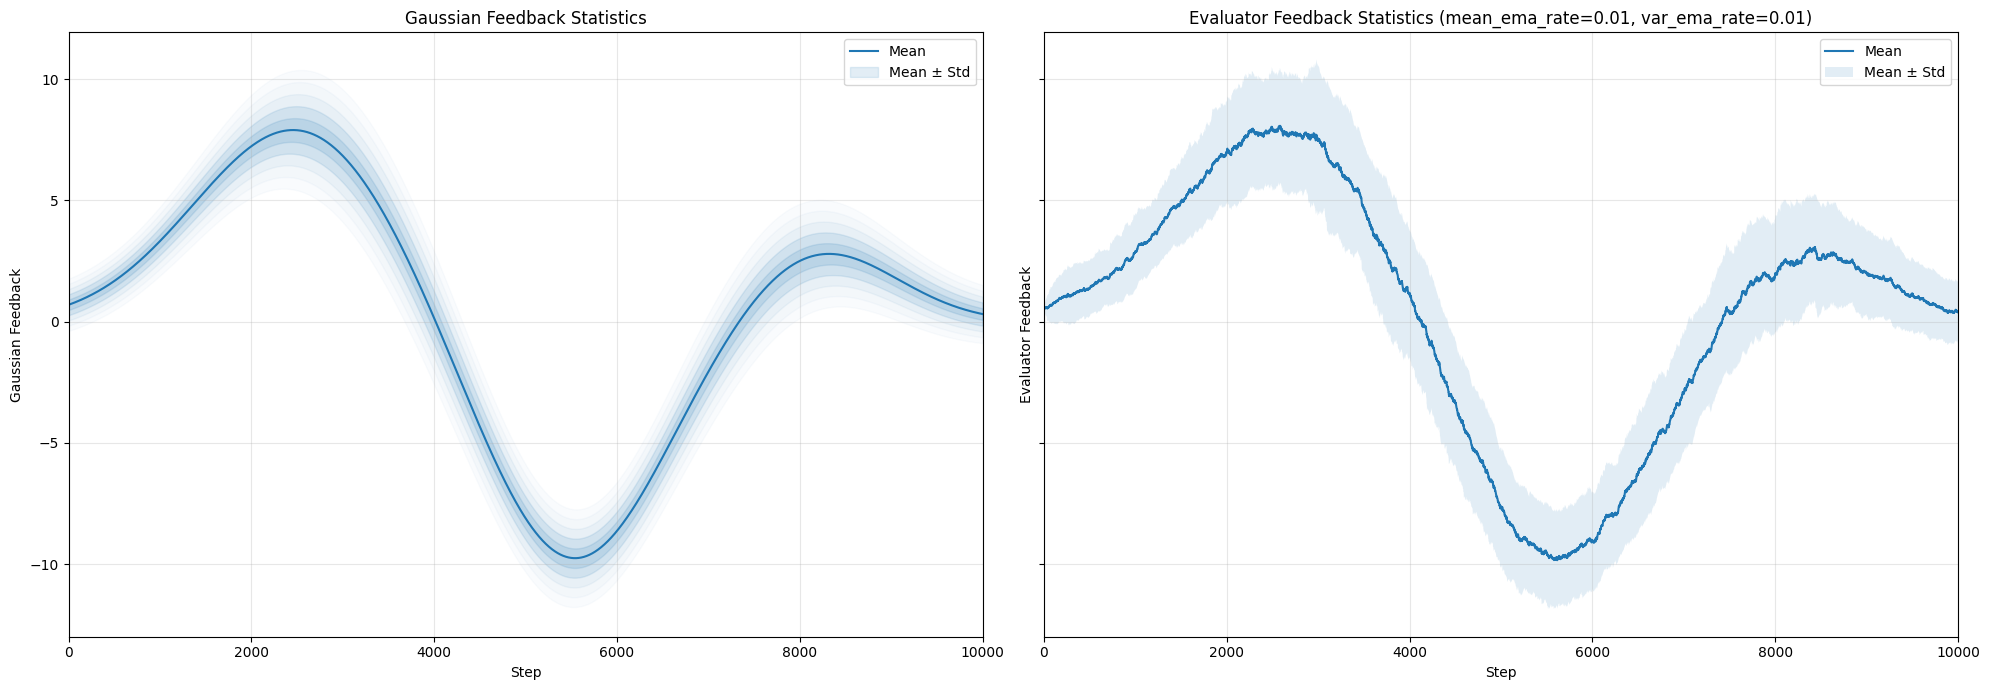

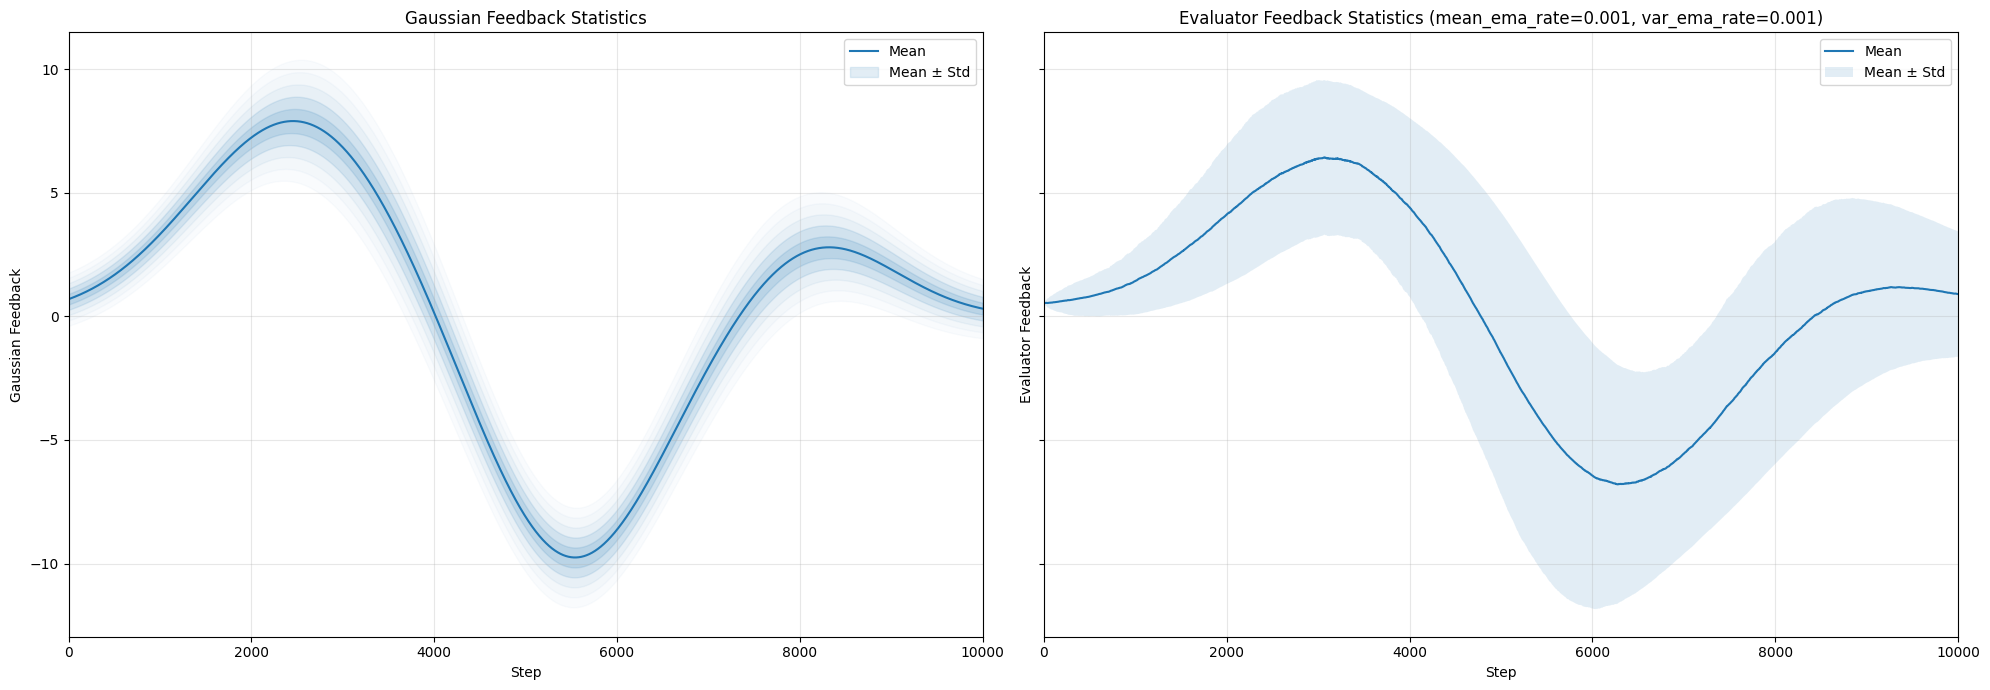

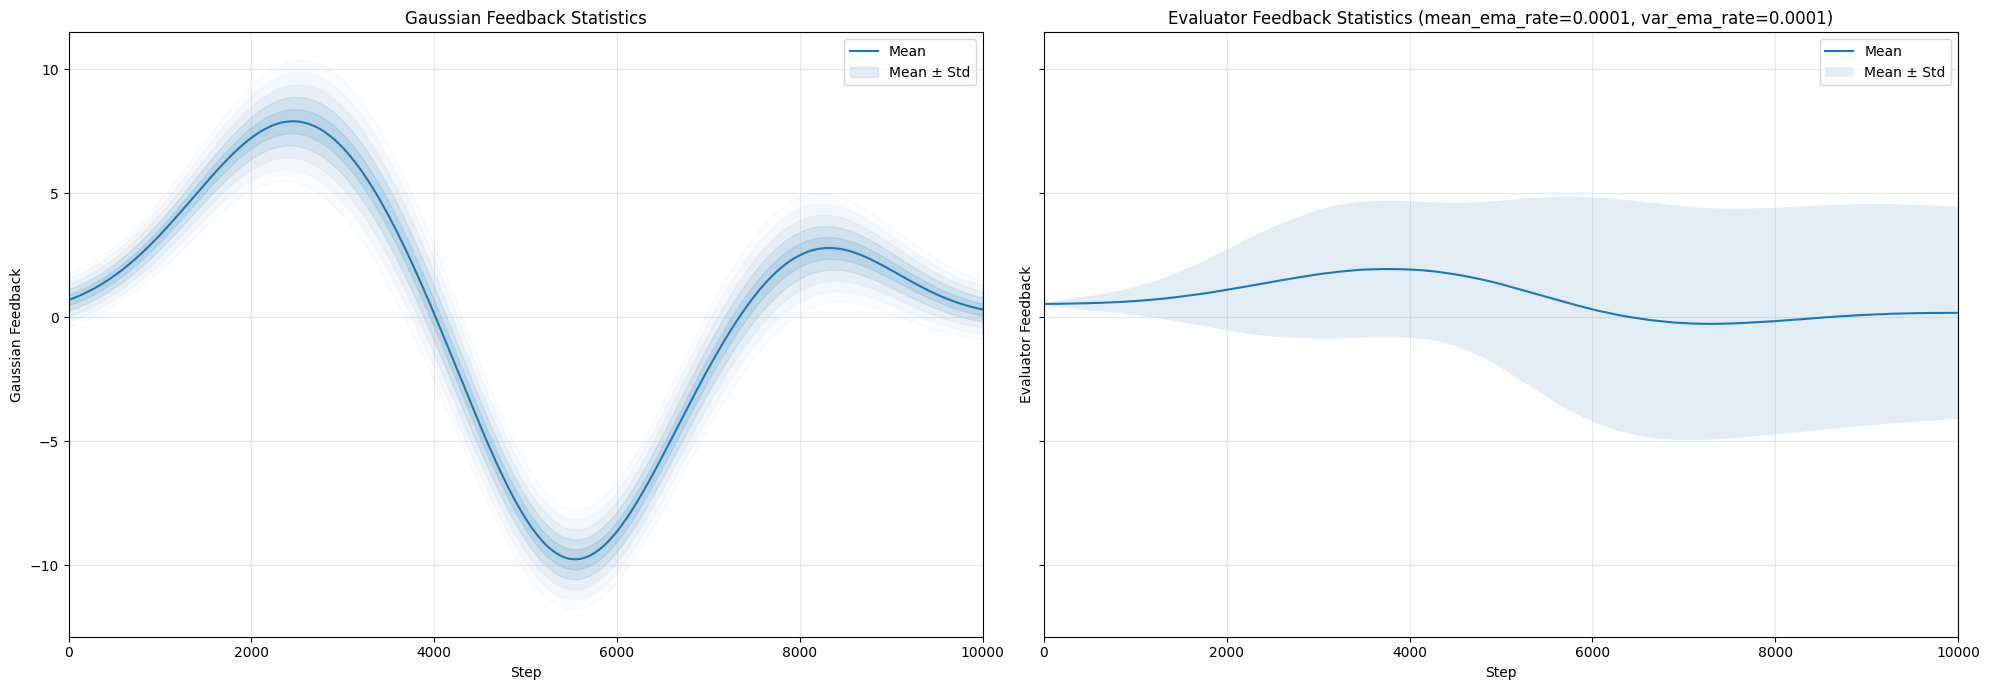

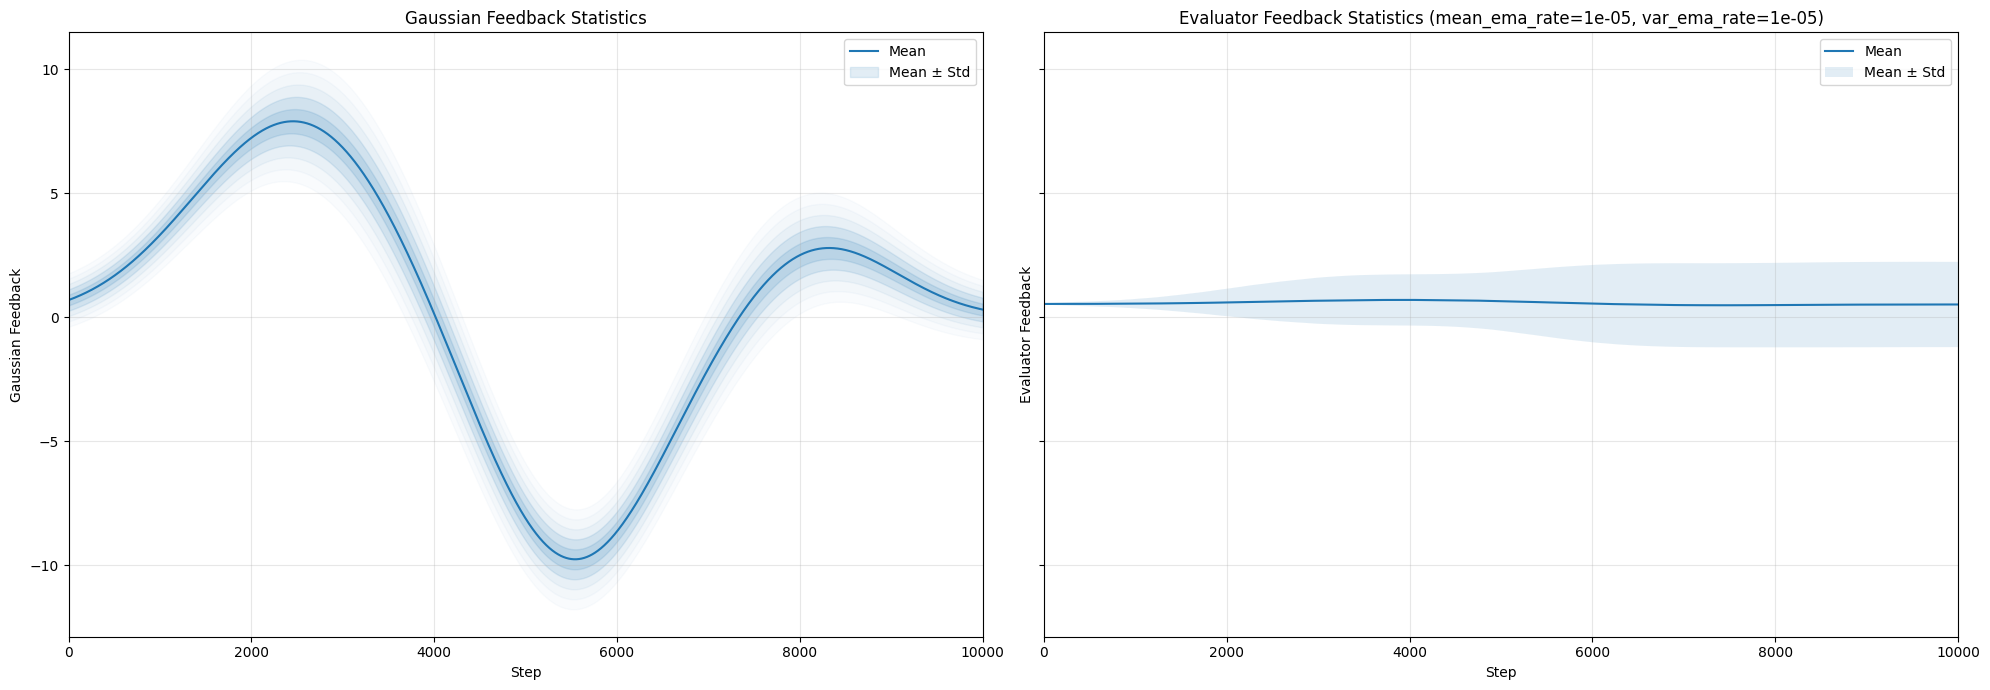

In [10]:
# define the list of EMA rates to evaluate
ema_rates = [
    (0.1, 0.1),
    (0.01, 0.01),
    (0.001, 0.001),
    (0.0001, 0.0001),
    (0.00001, 0.00001),
]

# run simulation for each EMA rate
for mean_ema_rate, var_ema_rate in ema_rates:
    means = []
    vars = []
    # initialize a ZScoreEvaluator
    evaluator = ZScoreEvaluator(
        mean_ema_rate=mean_ema_rate,
        var_ema_rate=var_ema_rate,
    )
    # initialize the random number generator
    rng = random.Random(SEED)
    # run simulation
    for step in range(N_STEPS):
        feedback = sample_feedback(step, mean_function, var_function, rng)
        evaluator(feedback)
        # update the simulation history
        mean = evaluator.mean if evaluator.mean is not None else math.nan
        var = evaluator.var if evaluator.var is not None else math.nan
        means.append(mean)
        vars.append(var)
    # plot the evaluator statistics
    fig, ax = plt.subplots(ncols=2, figsize=(20, 7), sharey=True)
    plot_feedback_statistics(ax[0], mean_function, var_function)
    plot_evaluator_statistics(ax[1], means, vars)
    ax[1].set_title(
        f"Evaluator Feedback Statistics "
        f"(mean_ema_rate={mean_ema_rate}, var_ema_rate={var_ema_rate})"
    )
    fig.tight_layout()
    plt.show()